In [3]:
#Uploading file to Colab
from google.colab import files
uploaded = files.upload()

Saving Toddler Autism dataset July 2018.csv to Toddler Autism dataset July 2018 (1).csv


In [4]:
#Reading Dataset
import pandas as pd
import io
data = pd.read_csv(io.BytesIO(uploaded['Toddler Autism dataset July 2018.csv']))# Dataset is now stored in a Pandas Dataframe

ValueError: could not convert string to float: 'f'

In [5]:
#Label Encoding (Converting all fields in numeric form)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data.Sex = label_encoder.fit_transform(data.Sex)
print(data.Sex)
data.Ethnicity = label_encoder.fit_transform(data.Ethnicity)
print(data.Ethnicity)
data.Jaundice = label_encoder.fit_transform(data.Jaundice)
print(data.Jaundice)
data.Family_mem_with_ASD = label_encoder.fit_transform(data.Family_mem_with_ASD)
print(data.Family_mem_with_ASD)
data.Class = label_encoder.fit_transform(data.Class)
print(data.Class)

0       0
1       1
2       1
3       1
4       0
       ..
1049    0
1050    1
1051    1
1052    1
1053    1
Name: Sex, Length: 1054, dtype: int64
0       8
1       5
2       8
3       0
4       5
       ..
1049    5
1050    7
1051    8
1052    5
1053    6
Name: Ethnicity, Length: 1054, dtype: int64
0       1
1       1
2       1
3       0
4       0
       ..
1049    0
1050    1
1051    1
1052    0
1053    1
Name: Jaundice, Length: 1054, dtype: int64
0       0
1       0
2       0
3       0
4       1
       ..
1049    1
1050    0
1051    0
1052    1
1053    1
Name: Family_mem_with_ASD, Length: 1054, dtype: int64
0       0
1       1
2       1
3       1
4       1
       ..
1049    0
1050    1
1051    1
1052    0
1053    1
Name: Class, Length: 1054, dtype: int64


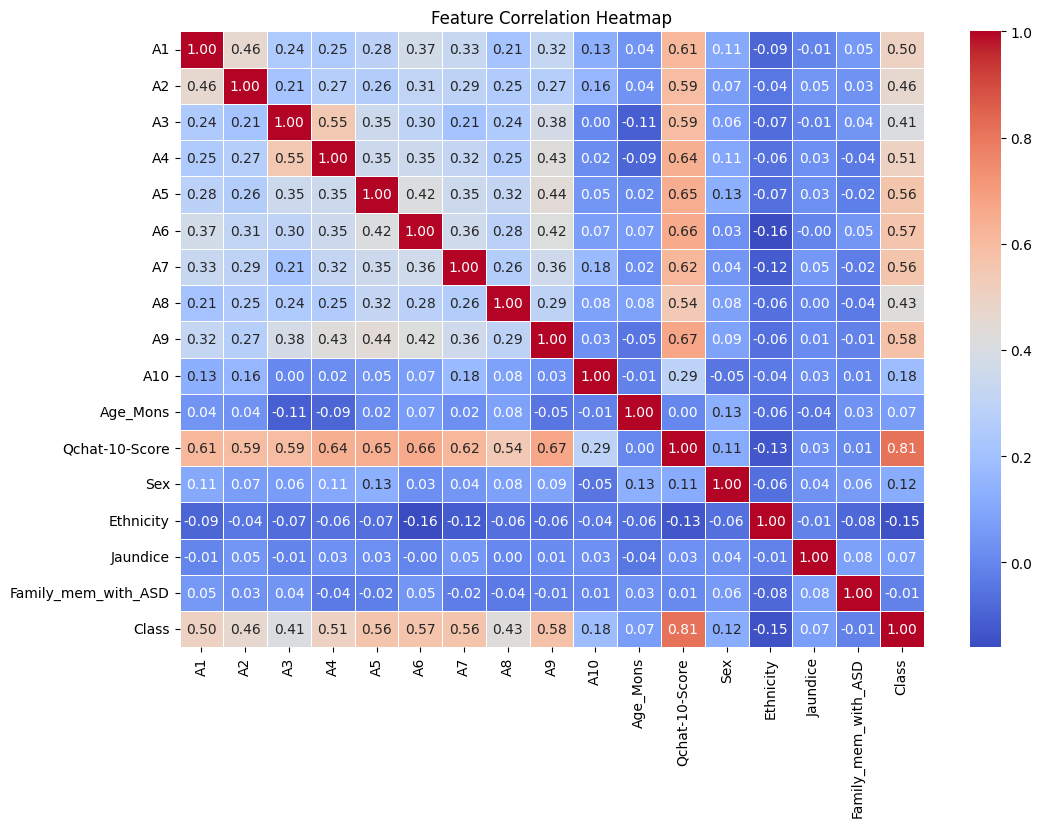

In [6]:
# Compute correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

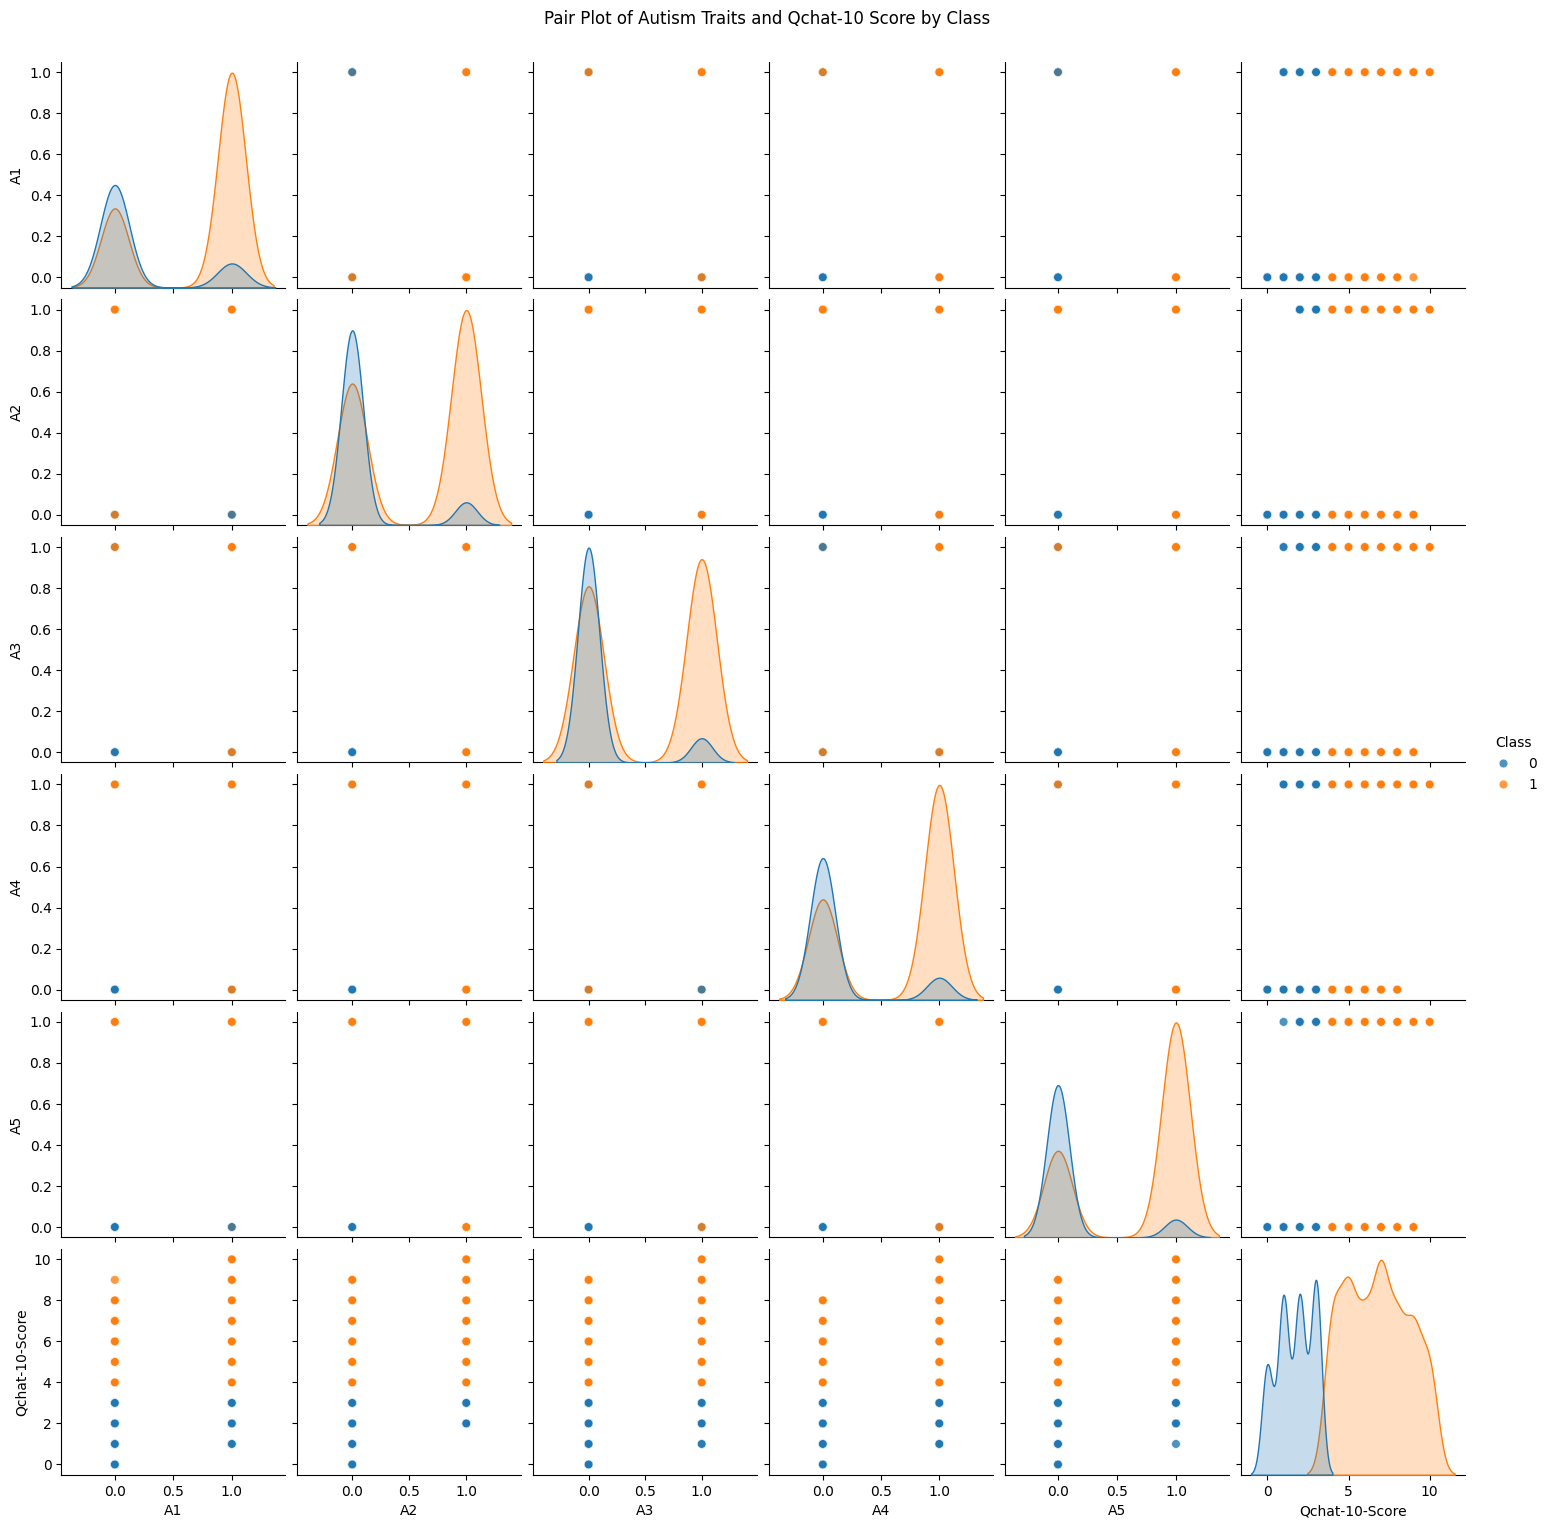

In [7]:
# Select the columns used in your pair plot
selected_features = ['A1', 'A2', 'A3', 'A4', 'A5', 'Qchat-10-Score', 'Class']

# Create the pair plot
sns.pairplot(data[selected_features], hue='Class', diag_kind='kde', plot_kws={'alpha': 0.8, 's': 40})
plt.suptitle('Pair Plot of Autism Traits and Qchat-10 Score by Class', y=1.02)
plt.show()

In [8]:
x = data.drop(columns=['Class'])  # Drop the target column to get features
y = data['Class']

SVM Accuracy= 0.994312668463612
[[324   2]
 [  4 724]]
SVM sensitivity= 0.9945054945054945
SVM specificity= 0.9938650306748467
SVM Precision= 0.9972451790633609
SVM Recall= 0.9945054945054945
SVM FMeasure 0.9958734525447042
SVM MCC = 0.9867088943943154
SVM Cohen's Kappa = 0.9866991965675346
SVM Log Loss = 0.019749166371395763


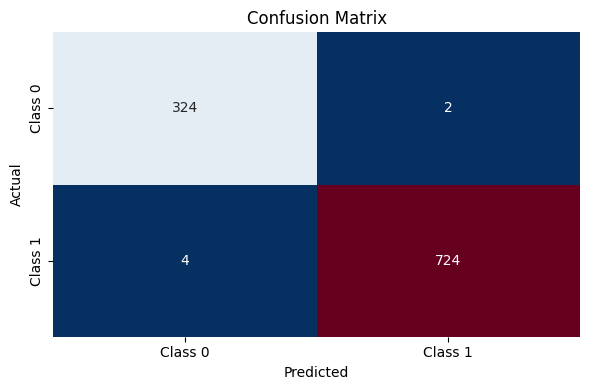

KNN Accuracy = 0.9744115004492363
[[314  12]
 [ 15 713]]
KNN Sensitivity = 0.9793956043956044
KNN Specificity = 0.9631901840490797
KNN Precision = 0.983448275862069
KNN Recall = 0.9793956043956044
KNN F-Measure = 0.981417756366139
KNN MCC = 0.9402177048698283
KNN Cohen's Kappa = 0.9401969478546301
KNNLog Loss = 0.13440620840210254


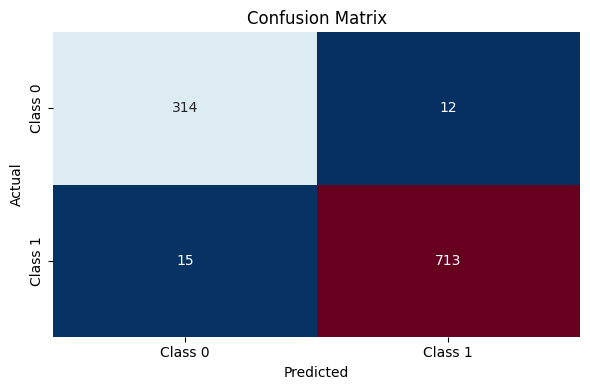

Decision Tree Accuracy = 1.0
[[326   0]
 [  0 728]]
Decision Tree Sensitivity = 1.0
Decision Tree Specificity = 1.0
Decision Tree Precision = 1.0
Decision Tree Recall = 1.0
Decision Tree F-Measure = 1.0
DT MCC = 1.0
DT Cohen's Kappa = 1.0
DT Log Loss = 2.2204460492503136e-16


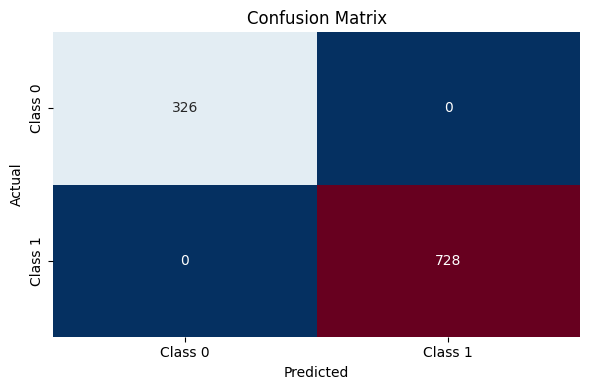

Naive Bayes Accuracy = 0.975318957771788
[[313  13]
 [ 13 715]]
Naive Bayes Sensitivity = 0.9821428571428571
Naive Bayes Specificity = 0.9601226993865031
Naive Bayes Precision = 0.9821428571428571
Naive Bayes Recall = 0.9821428571428571
Naive Bayes F-Measure = 0.9821428571428571
NB MCC = 0.9422655565293602
NB Cohen's Kappa = 0.9422655565293602
NB Log Loss = 0.05843523431780258


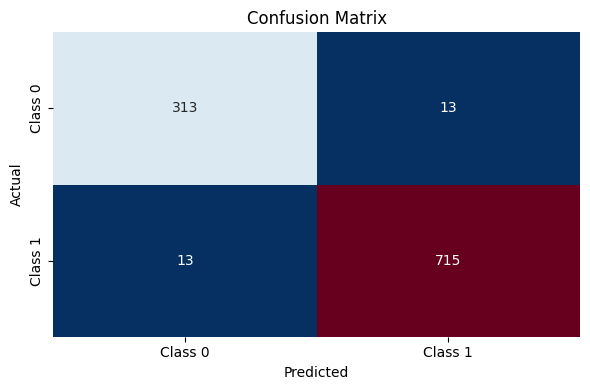

In [14]:
#Evaluating Classifiers' performance using k fold validation
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

sv=SVC(probability=True)
Accuracy=cross_val_score(sv, x, y,cv=10).mean()
print ("SVM Accuracy=", Accuracy)
y_pred = cross_val_predict(sv,x,y,cv=10)
confusion=metrics.confusion_matrix(y,y_pred)
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]
print (confusion)
sensitivity = TP / float(FN + TP)
print("SVM sensitivity=",sensitivity)
specificity = TN / (TN + FP)
print("SVM specificity=",specificity)
Precision = TP / float(TP + FP)
Recall = TP / float(TP + FN)
F1 = 2*((Precision*Recall)/(Precision+Recall))
print ("SVM Precision=",Precision)
print ("SVM Recall=", Recall)
print ("SVM FMeasure", F1)

# Matthews Correlation Coefficient (MCC)
mcc = metrics.matthews_corrcoef(y, y_pred)
print("SVM MCC =", mcc)

# Cohen's Kappa
kappa = metrics.cohen_kappa_score(y, y_pred)
print("SVM Cohen's Kappa =", kappa)

# Log Loss (requires predicted probabilities)
y_proba = cross_val_predict(sv, x, y, cv=10, method='predict_proba')
logloss = metrics.log_loss(y, y_proba)
print("SVM Log Loss =", logloss)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='RdBu_r', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Initialize the KNN model
knn = KNeighborsClassifier()

# Perform 10-fold cross-validation and calculate accuracy
Accuracy = cross_val_score(knn, x, y, cv=10).mean()
print("KNN Accuracy =", Accuracy)

# Perform cross-validation predictions
y_pred = cross_val_predict(knn, x, y, cv=10)

# Compute the confusion matrix
confusion = metrics.confusion_matrix(y, y_pred)
print(confusion)

# Extract true positives, true negatives, false positives, false negatives
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

# Calculate sensitivity
sensitivity = TP / float(FN + TP)
print("KNN Sensitivity =", sensitivity)

# Calculate specificity
specificity = TN / (TN + FP)
print("KNN Specificity =", specificity)

# Calculate precision, recall, and F1 score
Precision = TP / float(TP + FP)
Recall = TP / float(TP + FN)
F1 = 2 * ((Precision * Recall) / (Precision + Recall))
print("KNN Precision =", Precision)
print("KNN Recall =", Recall)
print("KNN F-Measure =", F1)


# Matthews Correlation Coefficient (MCC)
mcc = metrics.matthews_corrcoef(y, y_pred)
print("KNN MCC =", mcc)

# Cohen's Kappa
kappa = metrics.cohen_kappa_score(y, y_pred)
print("KNN Cohen's Kappa =", kappa)

# Log Loss (requires predicted probabilities)
y_proba = cross_val_predict(knn, x, y, cv=10, method='predict_proba')
logloss = metrics.log_loss(y, y_proba)
print("KNNLog Loss =", logloss)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='RdBu_r', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=1)

# Perform 10-fold cross-validation and calculate accuracy
Accuracy = cross_val_score(dt, x, y, cv=10).mean()
print("Decision Tree Accuracy =", Accuracy)

# Perform cross-validation predictions
y_pred = cross_val_predict(dt, x, y, cv=10)

# Compute the confusion matrix
confusion = metrics.confusion_matrix(y, y_pred)
print(confusion)

# Extract true positives, true negatives, false positives, false negatives
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

# Calculate sensitivity
sensitivity = TP / float(FN + TP)
print("Decision Tree Sensitivity =", sensitivity)

# Calculate specificity
specificity = TN / (TN + FP)
print("Decision Tree Specificity =", specificity)

# Calculate precision, recall, and F1 score
Precision = TP / float(TP + FP)
Recall = TP / float(TP + FN)
F1 = 2 * ((Precision * Recall) / (Precision + Recall))
print("Decision Tree Precision =", Precision)
print("Decision Tree Recall =", Recall)
print("Decision Tree F-Measure =", F1)



# Matthews Correlation Coefficient (MCC)
mcc = metrics.matthews_corrcoef(y, y_pred)
print("DT MCC =", mcc)

# Cohen's Kappa
kappa = metrics.cohen_kappa_score(y, y_pred)
print("DT Cohen's Kappa =", kappa)

# Log Loss (requires predicted probabilities)
y_proba = cross_val_predict(dt, x, y, cv=10, method='predict_proba')
logloss = metrics.log_loss(y, y_proba)
print("DT Log Loss =", logloss)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='RdBu_r', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
# Initialize the Naive Bayes model
nb = GaussianNB()

# Perform 10-fold cross-validation and calculate accuracy
Accuracy = cross_val_score(nb, x, y, cv=10).mean()
print("Naive Bayes Accuracy =", Accuracy)

# Perform cross-validation predictions
y_pred = cross_val_predict(nb, x, y, cv=10)

# Compute the confusion matrix
confusion = metrics.confusion_matrix(y, y_pred)
print(confusion)

# Extract true positives, true negatives, false positives, false negatives
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

# Calculate sensitivity
sensitivity = TP / float(FN + TP)
print("Naive Bayes Sensitivity =", sensitivity)

# Calculate specificity
specificity = TN / (TN + FP)
print("Naive Bayes Specificity =", specificity)

# Calculate precision, recall, and F1 score
Precision = TP / float(TP + FP)
Recall = TP / float(TP + FN)
F1 = 2 * ((Precision * Recall) / (Precision + Recall))
print("Naive Bayes Precision =", Precision)
print("Naive Bayes Recall =", Recall)
print("Naive Bayes F-Measure =", F1)


# Matthews Correlation Coefficient (MCC)
mcc = metrics.matthews_corrcoef(y, y_pred)
print("NB MCC =", mcc)

# Cohen's Kappa
kappa = metrics.cohen_kappa_score(y, y_pred)
print("NB Cohen's Kappa =", kappa)

# Log Loss (requires predicted probabilities)
y_proba = cross_val_predict(nb, x, y, cv=10, method='predict_proba')
logloss = metrics.log_loss(y, y_proba)
print("NB Log Loss =", logloss)
# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='RdBu_r', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()



In [15]:
#Evaluating Classifiers' performance using 70-30 Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Splitting data into train and test sets (70-30 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# Function to train and evaluate a model
def evaluate_model(model, name):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = metrics.accuracy_score(y_test, y_pred)
    confusion = metrics.confusion_matrix(y_test, y_pred)

    TP = confusion[1, 1]
    TN = confusion[0, 0]
    FP = confusion[0, 1]
    FN = confusion[1, 0]

    sensitivity = TP / float(FN + TP)
    specificity = TN / float(TN + FP)
    precision = TP / float(TP + FP) if (TP + FP) > 0 else 0
    recall = TP / float(TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * ((precision * recall) / (precision + recall)) if (precision + recall) > 0 else 0

    mcc = metrics.matthews_corrcoef(y_test, y_pred)
    kappa = metrics.cohen_kappa_score(y_test, y_pred)
    log_loss = metrics.log_loss(y_test, y_pred_proba) if y_pred_proba is not None else None
    roc_auc = metrics.roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    print(f"\n{name} Model Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{confusion}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Measure: {f1_score:.4f}")
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
    print(f"Cohen's Kappa Score: {kappa:.4f}")
    print(f"Log-Loss: {log_loss:.4f}" if log_loss is not None else "Log-Loss: Not applicable")
    print(f"ROC-AUC Score: {roc_auc:.4f}" if roc_auc is not None else "ROC-AUC Score: Not applicable")
    print("-" * 50)

# List of models to train and evaluate
models = {

    "SVM": SVC(probability=True),  # Enable probability for SVM
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate each model
for name, model in models.items():
    evaluate_model(model, name)


SVM Model Evaluation:
Accuracy: 0.9937
Confusion Matrix:
[[ 82   0]
 [  2 233]]
Sensitivity (Recall): 0.9915
Specificity: 1.0000
Precision: 1.0000
F1-Measure: 0.9957
Matthews Correlation Coefficient (MCC): 0.9838
Cohen's Kappa Score: 0.9837
Log-Loss: 0.0296
ROC-AUC Score: 0.9997
--------------------------------------------------

KNN Model Evaluation:
Accuracy: 0.9748
Confusion Matrix:
[[ 80   2]
 [  6 229]]
Sensitivity (Recall): 0.9745
Specificity: 0.9756
Precision: 0.9913
F1-Measure: 0.9828
Matthews Correlation Coefficient (MCC): 0.9357
Cohen's Kappa Score: 0.9352
Log-Loss: 0.0729
ROC-AUC Score: 0.9964
--------------------------------------------------

Decision Tree Model Evaluation:
Accuracy: 1.0000
Confusion Matrix:
[[ 82   0]
 [  0 235]]
Sensitivity (Recall): 1.0000
Specificity: 1.0000
Precision: 1.0000
F1-Measure: 1.0000
Matthews Correlation Coefficient (MCC): 1.0000
Cohen's Kappa Score: 1.0000
Log-Loss: 0.0000
ROC-AUC Score: 1.0000
---------------------------------------------

In [16]:
#Evaluating Classifiers' performance using 80-20 Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Splitting data into train and test sets (80-20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Function to train and evaluate a model
def evaluate_model(model, name):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = metrics.accuracy_score(y_test, y_pred)
    confusion = metrics.confusion_matrix(y_test, y_pred)

    TP = confusion[1, 1]
    TN = confusion[0, 0]
    FP = confusion[0, 1]
    FN = confusion[1, 0]

    sensitivity = TP / float(FN + TP)
    specificity = TN / float(TN + FP)
    precision = TP / float(TP + FP) if (TP + FP) > 0 else 0
    recall = TP / float(TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * ((precision * recall) / (precision + recall)) if (precision + recall) > 0 else 0

    mcc = metrics.matthews_corrcoef(y_test, y_pred)
    kappa = metrics.cohen_kappa_score(y_test, y_pred)
    log_loss = metrics.log_loss(y_test, y_pred_proba) if y_pred_proba is not None else None
    roc_auc = metrics.roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    print(f"\n{name} Model Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{confusion}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Measure: {f1_score:.4f}")
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
    print(f"Cohen's Kappa Score: {kappa:.4f}")
    print(f"Log-Loss: {log_loss:.4f}" if log_loss is not None else "Log-Loss: Not applicable")
    print(f"ROC-AUC Score: {roc_auc:.4f}" if roc_auc is not None else "ROC-AUC Score: Not applicable")
    print("-" * 50)

# List of models to train and evaluate
models = {

    "SVM": SVC(probability=True),  # Enable probability for SVM
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate each model
for name, model in models.items():
    evaluate_model(model, name)


SVM Model Evaluation:
Accuracy: 0.9905
Confusion Matrix:
[[ 58   0]
 [  2 151]]
Sensitivity (Recall): 0.9869
Specificity: 1.0000
Precision: 1.0000
F1-Measure: 0.9934
Matthews Correlation Coefficient (MCC): 0.9767
Cohen's Kappa Score: 0.9765
Log-Loss: 0.0229
ROC-AUC Score: 1.0000
--------------------------------------------------

KNN Model Evaluation:
Accuracy: 0.9668
Confusion Matrix:
[[ 56   2]
 [  5 148]]
Sensitivity (Recall): 0.9673
Specificity: 0.9655
Precision: 0.9867
F1-Measure: 0.9769
Matthews Correlation Coefficient (MCC): 0.9187
Cohen's Kappa Score: 0.9181
Log-Loss: 0.0803
ROC-AUC Score: 0.9954
--------------------------------------------------

Decision Tree Model Evaluation:
Accuracy: 1.0000
Confusion Matrix:
[[ 58   0]
 [  0 153]]
Sensitivity (Recall): 1.0000
Specificity: 1.0000
Precision: 1.0000
F1-Measure: 1.0000
Matthews Correlation Coefficient (MCC): 1.0000
Cohen's Kappa Score: 1.0000
Log-Loss: 0.0000
ROC-AUC Score: 1.0000
---------------------------------------------

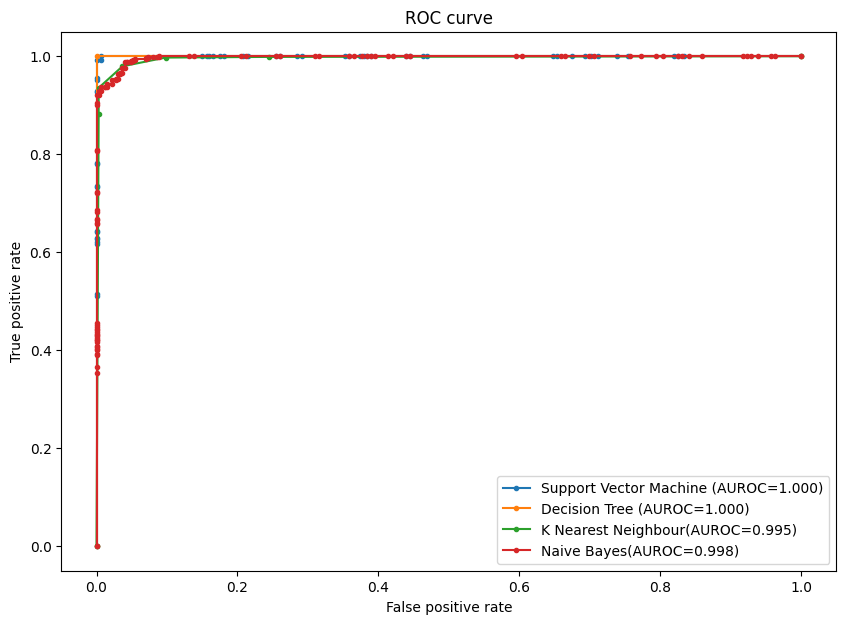

In [17]:
#Combined ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict
plt.figure(figsize=(10, 7))

sv=SVC(probability=True)

sv_probs = cross_val_predict(sv,x,y,cv=10,method='predict_proba')
sv_probs = sv_probs[:, 1]
sv_auc = roc_auc_score(y, sv_probs)
sv_fpr, sv_tpr, _ = roc_curve(y, sv_probs)
plt.plot(sv_fpr, sv_tpr, marker='.', label='Support Vector Machine (AUROC=%0.3f)'%sv_auc)

dt_probs = cross_val_predict(dt,x,y,cv=10,method='predict_proba')
dt_probs = dt_probs[:, 1]
dt_auc = roc_auc_score(y, dt_probs)
dt_fpr, dt_tpr, _ = roc_curve(y, dt_probs)
plt.plot(dt_fpr, dt_tpr, marker='.', label='Decision Tree (AUROC=%0.3f)'%sv_auc)



knn_probs = cross_val_predict(knn,x,y,cv=10,method='predict_proba')
knn_probs = knn_probs[:, 1]
knn_auc = roc_auc_score(y, knn_probs)
knn_fpr, knn_tpr, _ = roc_curve(y, knn_probs)
plt.plot(knn_fpr, knn_tpr, marker='.', label='K Nearest Neighbour(AUROC=%0.3f)'%knn_auc)

nb_probs = cross_val_predict(nb,x,y,cv=10,method='predict_proba')
nb_probs = nb_probs[:, 1]
nb_auc = roc_auc_score(y, nb_probs)
nb_fpr, nb_tpr, _ = roc_curve(y, nb_probs)
plt.plot(nb_fpr, nb_tpr, marker='.', label='Naive Bayes(AUROC=%0.3f)'%nb_auc)



plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

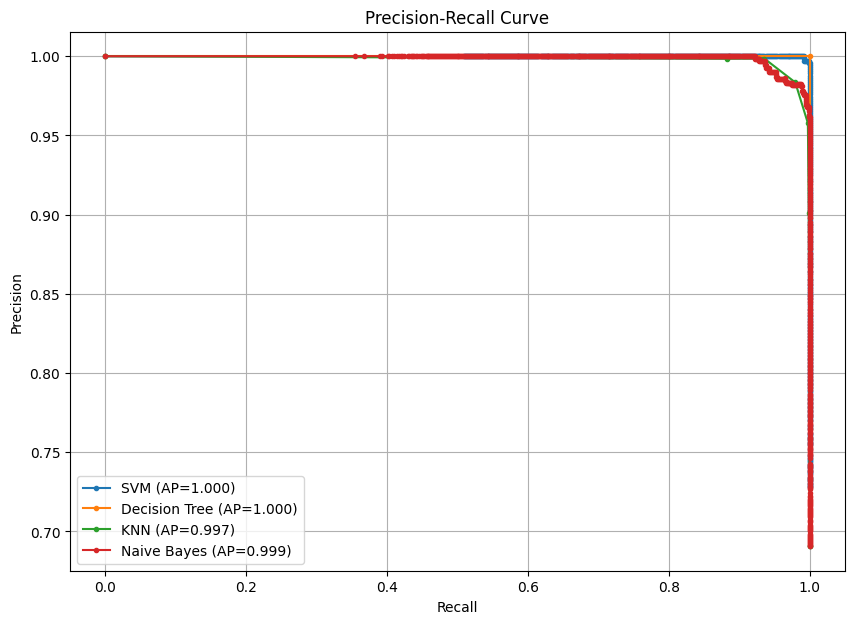

In [18]:
# Combined Precision-Recall Curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC

plt.figure(figsize=(10, 7))

# Support Vector Machine
sv = SVC(probability=True)
sv_probs = cross_val_predict(sv, x, y, cv=10, method='predict_proba')
sv_probs = sv_probs[:, 1]
sv_ap = average_precision_score(y, sv_probs)
sv_precision, sv_recall, _ = precision_recall_curve(y, sv_probs)
plt.plot(sv_recall, sv_precision, marker='.', label='SVM (AP=%0.3f)' % sv_ap)

# Decision Tree
dt_probs = cross_val_predict(dt, x, y, cv=10, method='predict_proba')
dt_probs = dt_probs[:, 1]
dt_ap = average_precision_score(y, dt_probs)
dt_precision, dt_recall, _ = precision_recall_curve(y, dt_probs)
plt.plot(dt_recall, dt_precision, marker='.', label='Decision Tree (AP=%0.3f)' % dt_ap)

# K-Nearest Neighbors
knn_probs = cross_val_predict(knn, x, y, cv=10, method='predict_proba')
knn_probs = knn_probs[:, 1]
knn_ap = average_precision_score(y, knn_probs)
knn_precision, knn_recall, _ = precision_recall_curve(y, knn_probs)
plt.plot(knn_recall, knn_precision, marker='.', label='KNN (AP=%0.3f)' % knn_ap)

# Naive Bayes
nb_probs = cross_val_predict(nb, x, y, cv=10, method='predict_proba')
nb_probs = nb_probs[:, 1]
nb_ap = average_precision_score(y, nb_probs)
nb_precision, nb_recall, _ = precision_recall_curve(y, nb_probs)
plt.plot(nb_recall, nb_precision, marker='.', label='Naive Bayes (AP=%0.3f)' % nb_ap)

# Plot formatting
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()